# CardioIA — Fase 2 · Parte 1: extração de sintomas e sugestão de diagnóstico

> ⚠️ **AVISO CLÍNICO:** Este sistema é um protótipo acadêmico e **NÃO** substitui avaliação médica.  
> Supervisionado por Dra. Fernanda Fassina (CRM-SP 169944).

**Objetivo.** Ler relatos livres de pacientes (`data/relatos_pacientes.txt`), identificar sintomas e contexto e sugerir **uma** condição possível com base no mapa de conhecimento (`knowledge_base/`).

**Como o sistema decide** — cada passo é explicável e rastreável até uma fonte científica:

```
relato ──► normalização ──► expressões do paciente → sintomas (conceitos)
                         └► gatilhos de contexto  → atributos (esforço, repouso, irradiação...)
                         └► negação ("não sinto dor no peito" não conta)
        ──► associações da base (sintoma → condição, com tipo de relação e fonte)
        ──► pontuação explicativa ──► sugestão principal (ou "inconclusivo" se houver empate)
```

O código fica em `fase2/src/` e é coberto pelo harness de testes (`fase2/tests/`). Este notebook só **demonstra** o pipeline.


In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def achar_pasta_fase2():
    """Localiza fase2/ a partir de onde o notebook está sendo executado."""
    for pasta in [Path.cwd(), *Path.cwd().parents]:
        for candidata in (pasta, pasta / "fase2"):
            if (candidata / "src" / "extrator_sintomas.py").exists():
                return candidata
    raise FileNotFoundError("pasta fase2/ não encontrada")


FASE2 = achar_pasta_fase2()
sys.path.insert(0, str(FASE2 / "src"))

from analisador_clinico import PESOS_RELACAO, analisar_relato
from carregador_base import carregar_base_conhecimento, carregar_relatos
from extrator_sintomas import extrair_conceitos, normalizar_texto, tokenizar

pd.set_option("display.max_colwidth", 120)
base = carregar_base_conhecimento()
nome_conceito = {c["conceito_id"]: c["conceito_clinico"] for c in base["conceitos"]}

## 1. O mapa de conhecimento

A base separa **como o paciente fala** (expressão) do **conceito clínico** e do **contexto**, e liga cada conceito a condições por meio de associações com fonte científica. São cinco tabelas ligadas por IDs:

In [2]:
pd.DataFrame(
    [
        ("conceitos.csv", "sintoma clínico normalizado", len(base["conceitos"])),
        ("expressoes.csv", "jeito de o paciente dizer o sintoma", len(base["expressoes"])),
        ("atributos.csv", "contexto: posição, esforço, repouso, duração, irradiação...", len(base["atributos"])),
        ("associacoes.csv", "sintoma → condição, com tipo de relação e fonte", len(base["associacoes"])),
        ("fontes.csv", "diretrizes e revisões científicas", len(base["fontes"])),
    ],
    columns=["arquivo", "o que guarda", "linhas"],
)

,arquivo,o que guarda,linhas
0,conceitos.csv,sintoma clínico normalizado,21
1,expressoes.csv,jeito de o paciente dizer o sintoma,99
2,atributos.csv,"contexto: posição, esforço, repouso, duração, irradiação...",23
3,associacoes.csv,"sintoma → condição, com tipo de relação e fonte",29
4,fontes.csv,diretrizes e revisões científicas,7


Para o formato pedido no enunciado (`Sintoma 1 | Sintoma 2 | Doença Associada`), a base é achatada em `knowledge_base/mapa_conhecimento.csv` pelo script `src/gerar_mapa_conhecimento.py`. Cada linha traz duas formas de relatar o mesmo sintoma e a condição associada, com o peso e a fonte. O arquivo é **derivado**: um teste garante que ele está sincronizado com a base.

In [3]:
mapa = pd.read_csv(FASE2 / "knowledge_base" / "mapa_conhecimento.csv", encoding="utf-8-sig")
print(f"{len(mapa)} linhas no mapa achatado")
mapa.head(8)

82 linhas no mapa achatado


,sintoma_1,sintoma_2,doenca_associada,conceito_clinico,tipo_relacao,peso,fontes,associacao_id
0,falta de ar,ficar sem ar,Insuficiência Cardíaca,Dispneia,sintoma típico,2,F001,AS001
1,fico sem ar,ficando sem ar,Insuficiência Cardíaca,Dispneia,sintoma típico,2,F001,AS001
2,dificuldade para respirar,respiração difícil,Insuficiência Cardíaca,Dispneia,sintoma típico,2,F001,AS001
3,falta de ar quando me deito,falta de ar ao deitar,Insuficiência Cardíaca,Ortopneia,sintoma típico,2,F001,AS002
4,respiração piora quando me deito,respiração piora deitado,Insuficiência Cardíaca,Ortopneia,sintoma típico,2,F001,AS002
5,quando me deito para dormir,respiração piora deitada,Insuficiência Cardíaca,Ortopneia,sintoma típico,2,F001,AS002
6,acordo de madrugada com falta de ar,acordo à noite com falta de ar,Insuficiência Cardíaca,Dispneia paroxística noturna,sintoma típico,2,F001,AS003
7,falta de ar me acorda,acordo sem conseguir respirar,Insuficiência Cardíaca,Dispneia paroxística noturna,sintoma típico,2,F001,AS003


In [4]:
mapa.groupby("doenca_associada").agg(
    linhas=("sintoma_1", "size"),
    sintomas_distintos=("conceito_clinico", "nunique"),
).sort_values("linhas", ascending=False)

,linhas,sintomas_distintos
doenca_associada,,
Insuficiência Cardíaca,36,13
IAM / Síndrome Coronariana Aguda,22,9
Angina / Doença Coronariana,15,4
Congestão / contexto cardiorrenal,9,3


Nem toda associação vale o mesmo. O **tipo de relação** registrado na base vira um peso na pontuação: um sintoma típico pesa mais que um sintoma apenas associado. Assim a falta de ar, que aparece em quase todas as condições, não decide a sugestão sozinha.

In [5]:
pd.DataFrame(sorted(PESOS_RELACAO.items(), key=lambda item: -item[1]), columns=["tipo_relacao", "peso"])

,tipo_relacao,peso
0,manifestação principal,3
1,sintoma típico,2
2,manifestação contextual,2
3,sintoma menos típico,1
4,sintoma associado,1
5,manifestação compartilhada,1


## 2. Os 10 relatos

Relatos **sintéticos** (nenhum dado real de paciente), cada um com o sintoma, quando começou e o impacto na rotina.

In [6]:
relatos = carregar_relatos()
pd.DataFrame(relatos).rename(columns={"id": "relato"})

,relato,texto
0,RELATO 01,"Há cerca de duas semanas comecei a ficar sem ar quando caminho até o mercado. Antes fazia esse trajeto normalmente, ..."
1,RELATO 02,"Nos últimos dias tenho sentido falta de ar quando me deito para dormir. Minha respiração melhora quando me sento, e ..."
2,RELATO 03,Faz aproximadamente uma semana que acordo de madrugada com muita falta de ar. Preciso me sentar por alguns minutos p...
3,RELATO 04,"Hoje comecei de repente a sentir um aperto forte no peito enquanto estava sentado. Já faz mais de vinte minutos, não..."
4,RELATO 05,"Desde ontem estou tendo episódios de desconforto no peito. Em um deles fiquei tonto, parecia que eu ia desmaiar e di..."
5,RELATO 06,"Há cerca de um mês sinto uma pressão no peito quando subo escadas ou caminho rápido. Quando paro e descanso, ela mel..."
6,RELATO 07,"Eu sentia aperto no peito apenas quando fazia bastante esforço, mas nesta última semana ele começou a acontecer com ..."
7,RELATO 08,Nos últimos dias minhas pernas e meus tornozelos começaram a ficar inchados. Também percebi que estou urinando bem m...
8,RELATO 09,Há alguns dias percebi que meu peso aumentou rapidamente e comecei a acordar várias vezes durante a noite para urina...
9,RELATO 10,Nas últimas semanas perdi o apetite e emagreci sem querer. Também tenho sentido desconforto na barriga e muito cansa...


## 3. Como o extrator lê o texto

**Normalização.** Minúsculas, sem acento e sem pontuação: "Pressão no PEITO!" e "pressao no peito" viram a mesma coisa. As expressões são procuradas como palavras inteiras.

In [7]:
for texto in ["Pressão no PEITO!", "pressao no peito", "Fiquei TONTA e pálida."]:
    print(f"{texto!r:28} → {normalizar_texto(texto)!r}")

'Pressão no PEITO!'          → 'pressao no peito'
'pressao no peito'           → 'pressao no peito'
'Fiquei TONTA e pálida.'     → 'fiquei tonta e palida'


**Negação** (versão simplificada do algoritmo NegEx). Um gatilho (`não`, `nem`, `sem`, `nunca`, `nenhum`...) anula o sintoma que aparece até 3 palavras depois, na mesma oração. Pontuação e conjunções como `mas` e `só` encerram o alcance. Locuções como "fico **sem ar**" ou "não aguento" não negam o que vem depois, e "**quase** desmaiei" é pré-síncope, não síncope. Os sintomas negados não pontuam, mas são exibidos.

In [8]:
exemplos = [
    "Não sinto dor no peito nem falta de ar.",
    "Não sinto dor no peito, só um cansaço leve.",
    "Não tenho dor no peito, mas fico sem ar quando caminho.",
    "Quase desmaiei ontem e fiquei muito pálida.",
    "Não acordo de madrugada com falta de ar.",
    "Não aguento mais esse cansaço.",
]


def nomes(ids):
    return ", ".join(nome_conceito[i] for i in sorted(ids)) or "—"


linhas = []
for frase in exemplos:
    conceitos = extrair_conceitos(frase, base["expressoes"], incluir_negados=True)
    linhas.append({
        "frase": frase,
        "sintomas afirmados": nomes(c["conceito_id"] for c in conceitos if not c["negado"]),
        "sintomas negados": nomes(c["conceito_id"] for c in conceitos if c["negado"]),
    })
pd.DataFrame(linhas)

,frase,sintomas afirmados,sintomas negados
0,Não sinto dor no peito nem falta de ar.,—,"Dispneia, Dor/desconforto torácico"
1,"Não sinto dor no peito, só um cansaço leve.",Fadiga/cansaço,Dor/desconforto torácico
2,"Não tenho dor no peito, mas fico sem ar quando caminho.",Dispneia,Dor/desconforto torácico
3,Quase desmaiei ontem e fiquei muito pálida.,"Tontura/pré-síncope, Palidez",Síncope
4,Não acordo de madrugada com falta de ar.,—,"Dispneia, Dispneia paroxística noturna"
5,Não aguento mais esse cansaço.,Fadiga/cansaço,—


## 4. Resultado nos 10 relatos

Para cada relato: sintomas encontrados, contexto, a **sugestão principal** e a segunda hipótese. Pontuação = soma dos pesos das evidências + 1 por atributo de contexto relevante (é uma ordem explicável, **não** uma probabilidade).

In [9]:
analises = {r["id"]: analisar_relato(r["texto"], base) for r in relatos}

resumo = []
for relato_id, analise in analises.items():
    condicoes = analise["condicoes"]
    resumo.append({
        "relato": relato_id,
        "sintomas": nomes(c["conceito_id"] for c in analise["conceitos"]),
        "contexto": ", ".join(a["valor"] for a in analise["atributos"]) or "—",
        "sugestão principal": analise["sugestao"]["condicao"] or "inconclusivo",
        "pontos": analise["sugestao"]["pontuacao"],
        "2ª hipótese": f"{condicoes[1]['condicao']} ({condicoes[1]['pontuacao_explicativa']})" if len(condicoes) > 1 else "—",
    })
pd.DataFrame(resumo)

,relato,sintomas,contexto,sugestão principal,pontos,2ª hipótese
0,RELATO 01,"Dispneia, Fadiga/cansaço, Intolerância ao exercício",esforço,Insuficiência Cardíaca,7,Angina / Doença Coronariana (3)
1,RELATO 02,"Dispneia, Ortopneia","deitado, sentado, noturno",Insuficiência Cardíaca,7,Angina / Doença Coronariana (1)
2,RELATO 03,"Dispneia, Dispneia paroxística noturna",noturno,Insuficiência Cardíaca,5,Angina / Doença Coronariana (1)
3,RELATO 04,"Dor/desconforto torácico, Sudorese, Náusea","sentado, repouso, não melhora com repouso, início súbito, duração >20 min, braço, aperto/pressão",IAM / Síndrome Coronariana Aguda,11,Angina / Doença Coronariana (5)
4,RELATO 05,"Dor/desconforto torácico, Tontura/pré-síncope, Palidez",recorrente/previsível,IAM / Síndrome Coronariana Aguda,5,Angina / Doença Coronariana (4)
5,RELATO 06,Dor/desconforto torácico,"esforço, melhora com repouso, aperto/pressão",Angina / Doença Coronariana,6,IAM / Síndrome Coronariana Aguda (4)
6,RELATO 07,Dor/desconforto torácico,"esforço, repouso, progressivo, aperto/pressão, aumento de frequência, menor limiar de esforço",IAM / Síndrome Coronariana Aguda,8,Angina / Doença Coronariana (5)
7,RELATO 08,"Dispneia, Fadiga/cansaço, Oligúria, Edema periférico",esforço,Insuficiência Cardíaca,7,Congestão / contexto cardiorrenal (5)
8,RELATO 09,"Fadiga/cansaço, Tosse noturna, Ganho de peso, Noctúria",noturno,Insuficiência Cardíaca,6,Angina / Doença Coronariana (1)
9,RELATO 10,"Fadiga/cansaço, Perda de peso, Dor abdominal, Perda de apetite",—,Insuficiência Cardíaca,5,Angina / Doença Coronariana (1)


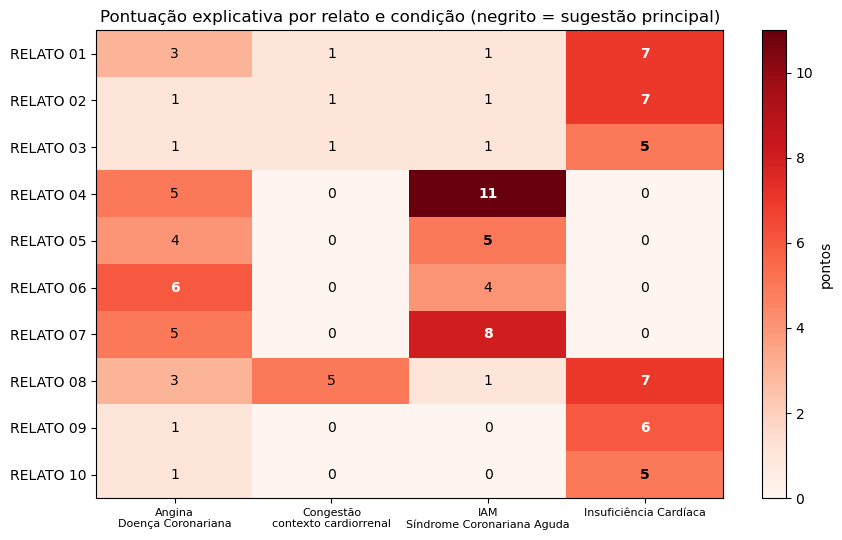

In [10]:
condicoes_ordenadas = sorted({c["condicao"] for a in analises.values() for c in a["condicoes"]})
matriz = pd.DataFrame(
    [
        {c["condicao"]: c["pontuacao_explicativa"] for c in analise["condicoes"]}
        for analise in analises.values()
    ],
    index=list(analises),
    columns=condicoes_ordenadas,
).fillna(0).astype(int)

fig, eixo = plt.subplots(figsize=(9, 5.5))
imagem = eixo.imshow(matriz.values, cmap="Reds", aspect="auto")
eixo.set_xticks(range(len(matriz.columns)), [c.replace(" / ", "\n") for c in matriz.columns], fontsize=8)
eixo.set_yticks(range(len(matriz.index)), matriz.index)
for linha in range(matriz.shape[0]):
    destaque = matriz.values[linha].max()
    for coluna in range(matriz.shape[1]):
        valor = matriz.values[linha, coluna]
        eixo.text(coluna, linha, valor, ha="center", va="center",
                  fontweight="bold" if valor == destaque else "normal",
                  color="white" if valor >= 6 else "black")
eixo.set_title("Pontuação explicativa por relato e condição (negrito = sugestão principal)")
fig.colorbar(imagem, ax=eixo, label="pontos")
plt.tight_layout()
plt.show()

## 5. Explicando uma sugestão: RELATO 04

O sistema mostra **por que** chegou à sugestão: cada evidência com seu peso, os atributos de contexto que reforçam a hipótese e as fontes da associação.

In [11]:
relato_id = "RELATO 04"
print(next(r["texto"] for r in relatos if r["id"] == relato_id), "\n")

pd.DataFrame([
    {
        "condição": c["condicao"],
        "evidências (peso)": "; ".join(f"{nome_conceito[e['conceito_id']]} ({e['tipo_relacao']}, +{e['peso']})" for e in c["evidencias"]),
        "contexto relevante": ", ".join(c["atributos"]) or "—",
        "fontes": ", ".join(c["fontes"]),
        "pontos": c["pontuacao_explicativa"],
    }
    for c in analises[relato_id]["condicoes"]
])

Hoje comecei de repente a sentir um aperto forte no peito enquanto estava sentado. Já faz mais de vinte minutos, não melhorou, a dor está indo para o meu braço e comecei a suar frio e sentir enjoo. 



,condição,evidências (peso),contexto relevante,fontes,pontos
0,IAM / Síndrome Coronariana Aguda,"Dor/desconforto torácico (manifestação principal, +3); Sudorese (sintoma associado, +1); Náusea (sintoma associado, +1)","A005, A007, A009, A012, A013, A019","F002, F003",11
1,Angina / Doença Coronariana,"Dor/desconforto torácico (manifestação principal, +3); Náusea (sintoma associado, +1)",A019,"F004, F005",5


In [12]:
titulos_fontes = {f["fonte_id"]: f"{f['titulo']} ({f['instituicao']}, {f['ano']})" for f in base["fontes"]}
for fonte_id in analises[relato_id]["condicoes"][0]["fontes"]:
    print(f"{fonte_id}: {titulos_fontes[fonte_id]}")

F002: Linha de Cuidado do Infarto Agudo do Miocárdio (Ministério da Saúde, s.d.)
F003: Acute Coronary Syndrome (American Heart Association, s.d.)


## 6. Conferência com o gabarito

O arquivo `tests/golden/relatos_esperados.json` registra, para cada relato, os sintomas que **precisam** ser encontrados e a condição esperada. Os mesmos casos rodam no harness (`pytest fase2`) a cada mudança.

In [13]:
gabarito = {
    chave: valor
    for chave, valor in json.loads((FASE2 / "tests" / "golden" / "relatos_esperados.json").read_text(encoding="utf-8")).items()
    if not chave.startswith("_")
}

conferencia = []
for relato_id, esperado in gabarito.items():
    analise = analises[relato_id]
    encontrados = {c["conceito_id"] for c in analise["conceitos"]}
    conferencia.append({
        "relato": relato_id,
        "sintomas obrigatórios encontrados": set(esperado["conceitos"]) <= encontrados,
        "esperado": esperado["condicao_principal"],
        "obtido": analise["sugestao"]["condicao"],
        "acertou": analise["sugestao"]["condicao"] == esperado["condicao_principal"],
    })
conferencia = pd.DataFrame(conferencia)
print(f"Sugestões corretas: {conferencia['acertou'].sum()}/{len(conferencia)}")
conferencia

Sugestões corretas: 10/10


,relato,sintomas obrigatórios encontrados,esperado,obtido,acertou
0,RELATO 01,True,Insuficiência Cardíaca,Insuficiência Cardíaca,True
1,RELATO 02,True,Insuficiência Cardíaca,Insuficiência Cardíaca,True
2,RELATO 03,True,Insuficiência Cardíaca,Insuficiência Cardíaca,True
3,RELATO 04,True,IAM / Síndrome Coronariana Aguda,IAM / Síndrome Coronariana Aguda,True
4,RELATO 05,True,IAM / Síndrome Coronariana Aguda,IAM / Síndrome Coronariana Aguda,True
5,RELATO 06,True,Angina / Doença Coronariana,Angina / Doença Coronariana,True
6,RELATO 07,True,IAM / Síndrome Coronariana Aguda,IAM / Síndrome Coronariana Aguda,True
7,RELATO 08,True,Insuficiência Cardíaca,Insuficiência Cardíaca,True
8,RELATO 09,True,Insuficiência Cardíaca,Insuficiência Cardíaca,True
9,RELATO 10,True,Insuficiência Cardíaca,Insuficiência Cardíaca,True


## 7. Limitações

- **Validação clínica pendente:** os pesos e a escolha do RELATO 08 (IC como principal, contexto cardiorrenal como 2ª hipótese) precisam ser validados pela Dra. Fernanda Fassina.
- **Vocabulário de livro:** expressões coloquiais fora da base ("agonia no peito", "apaguei") não são reconhecidas. O efeito é medido no notebook 03, não "decorado" na base.
- **Negação simplificada:** dupla negação ("não consigo fazer nada sem falta de ar") e negação posposta não são tratadas.
- **Tempo verbal:** não distingue sintoma passado de atual ("tive dor no peito há 5 anos").
- **Paridade de gênero:** um teste de contrato exige que toda expressão flexionada no gênero de quem relata ("estava sentado") tenha a forma do outro gênero. Ele encontrou e corrigiu lacunas reais da base (`estava sentada`, `mesmo estando parada`, `me deixando mais cansada`, `respiração piora deitada`).

Detalhes e rastreabilidade: `.spec/SDD-fase2-nlp-triagem.md` (§3 e §7).

---

> ⚠️ **AVISO CLÍNICO:** Este sistema é um protótipo acadêmico e **NÃO** substitui avaliação médica.  
> Supervisionado por Dra. Fernanda Fassina (CRM-SP 169944).